<a href="https://colab.research.google.com/github/lovnishverma/Python-Getting-Started/blob/main/PyTorch_for_Beginners_NIELIT_Ropar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PyTorch** for *Beginners*
### NIELIT Ropar - AIML with IIT Ropar
**Faculty:** Lovnish Verma | **Date:** April 2026

---

## What You Will Learn

| Sr no. | Topic | Difficulty |
|---|-------|------------|
| 1 | Setup & Environment Check | 🟢 Beginner |
| 2 | What is PyTorch? (Theory) | 🟢 Beginner |
| 3 | Tensors — The Core Building Block | 🟢 Beginner |
| 4 | Tensor Data Types | 🟢 Beginner |
| 5 | Tensor Operations | 🟡 Intermediate |
| 6 | GPU Acceleration | 🟡 Intermediate |
| 7 | Autograd — Automatic Differentiation | 🟡 Intermediate |
| 8 | Datasets & DataLoaders | 🟡 Intermediate |
| 9 | Custom Datasets | 🟠 Advanced |
| 10 | Building a Neural Network | 🟡 Intermediate |
| 11 | Loss Functions & Optimizers | 🟡 Intermediate |
| 12 | Training Loop | 🟠 Advanced |
| 13 | Evaluation Loop | 🟡 Intermediate |
| 14 | Save & Load Models | 🟢 Beginner |
| 15 | Make Predictions | 🟢 Beginner |

---


>
> **Goal:** By the end of this notebook you will have trained a real neural network that classifies 10 types of clothing with ~88% accuracy.

---

## Section 1: Setup & Environment Check

Before anything else, let's confirm PyTorch is installed and check if a GPU is available.

> 💡 **What is a GPU?** A Graphics Processing Unit (GPU) can run thousands of small calculations *in parallel*. For deep learning, this is critical — training that takes hours on CPU takes minutes on GPU.
>
> **In Colab:** Go to `Runtime → Change runtime type → T4 GPU` to enable free GPU access.

In [1]:
# Install PyTorch (already installed on Colab, but safe to run)
!pip install torch torchvision -q

import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np

print("✅ PyTorch version :", torch.__version__)
print("✅ TorchVision     :", torchvision.__version__)
print("✅ CUDA available  :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("✅ GPU name        :", torch.cuda.get_device_name(0))

# ─── Device selector: always use GPU when available ───
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("\n Using device   :", device)

✅ PyTorch version : 2.10.0+cu128
✅ TorchVision     : 0.25.0+cu128
✅ CUDA available  : True
✅ GPU name        : Tesla T4

 Using device   : cuda


---
## Section 2: What is PyTorch?

### 📖 Quick Theory (3 minutes)

| Feature | Meaning |
|---|---|
| **Open-source** | Free to use, created by Facebook AI (Meta) in 2016 |
| **Python-first** | Works seamlessly with NumPy, SciPy, pandas |
| **Dynamic graphs** | You can change network behaviour *while* it runs (unlike TensorFlow 1.x) |
| **Autograd** | Automatically computes gradients — the magic behind learning |
| **GPU ready** | Same code runs on CPU or GPU, just change one line |

### 🏗️ PyTorch Architecture (simplified)

```
Your Python Code
     ↓
   PyTorch API   ←── torch.nn, torch.optim, torchvision
     ↓
  C++ Core       ←── Tensor ops, CUDA kernels (fast!)
     ↓
  CPU / GPU
```

> You write clean Python. PyTorch translates it to blazing-fast C++/CUDA under the hood. Best of both worlds.

---
## Section 3: Tensors: The Core Building Block

### What is a Tensor?

A **tensor** is just a multi-dimensional array of numbers.

```
Scalar (0-D)     →  7
Vector (1-D)     →  [1, 2, 3]
Matrix (2-D)     →  [[1, 2], [3, 4]]
Tensor (3-D+)    →  [[[...], [...]], [[...], [...]]]
```

**Why tensors?** Images are 3-D tensors (Height × Width × Channels). Batches of images are 4-D. Every input, output, and weight in a neural network is a tensor.

---

### 3a: Creating Tensors

In [2]:
# Scalar (0-D tensor)
scalar = torch.tensor(7)
print("Scalar      :", scalar)
print("  ndim      :", scalar.ndim)   # number of dimensions = 0
print("  item()    :", scalar.item()) # extract the Python number
print()

Scalar      : tensor(7)
  ndim      : 0
  item()    : 7



In [3]:
# Vector (1-D tensor)
vector = torch.tensor([1, 2, 3])
print("Vector      :", vector)
print("  shape     :", vector.shape)  # torch.Size([3])
print("  ndim      :", vector.ndim)
print()

Vector      : tensor([1, 2, 3])
  shape     : torch.Size([3])
  ndim      : 1



In [4]:
# Matrix (2-D tensor)
matrix = torch.tensor([[1, 2, 3],
                        [4, 5, 6]])
print("Matrix:")
print(matrix)
print("  shape     :", matrix.shape)  # 2 rows × 3 cols
print("  ndim      :", matrix.ndim)
print()

Matrix:
tensor([[1, 2, 3],
        [4, 5, 6]])
  shape     : torch.Size([2, 3])
  ndim      : 2



In [5]:
# 3-D Tensor (a 'batch' of matrices)
tensor_3d = torch.tensor([[[1, 2],
                             [3, 4]],
                            [[5, 6],
                             [7, 8]]])
print("3-D Tensor:")
print(tensor_3d)
print("  shape     :", tensor_3d.shape)  # 2 × 2 × 2
print()

3-D Tensor:
tensor([[[1, 2],
         [3, 4]],

        [[5, 6],
         [7, 8]]])
  shape     : torch.Size([2, 2, 2])



### 3b: Built-in Tensor Factories

Most of the time you won't type numbers manually. PyTorch has factory functions:

In [6]:
# Zeros and Ones
zeros  = torch.zeros(3, 4)      # 3 rows, 4 cols, all 0
ones   = torch.ones(3, 4)       # 3 rows, 4 cols, all 1
print("zeros:\n", zeros)
print("\nones:\n", ones)

zeros:
 tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])

ones:
 tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])


In [7]:
# Random Tensors
# Uniform random between 0 and 1
rand_uniform = torch.rand(2, 3)
print("rand (uniform 0-1):\n", rand_uniform)

# Normal distribution (mean=0, std=1)
rand_normal  = torch.randn(2, 3)
print("\nrandn (normal):")
print(rand_normal)

rand (uniform 0-1):
 tensor([[0.0614, 0.1804, 0.9558],
        [0.2869, 0.5955, 0.4153]])

randn (normal):
tensor([[ 1.8245, -2.4276,  0.6512],
        [ 0.1028,  0.8813, -0.9843]])


In [8]:
# Reproducibility: manual seed
# If you need the SAME random values every run, set a seed

torch.manual_seed(42)
a = torch.rand(2, 2)

torch.manual_seed(42)   # reset seed
b = torch.rand(2, 2)

print("a == b?", torch.equal(a, b))  # True — same seed → same values
print(a)

a == b? True
tensor([[0.8823, 0.9150],
        [0.3829, 0.9593]])


In [9]:
# *_like  — same shape as another tensor
template = torch.rand(3, 5)

z = torch.zeros_like(template)   # zeros, same shape
o = torch.ones_like(template)    # ones, same shape
r = torch.rand_like(template)    # random, same shape

print("template shape  :", template.shape)
print("zeros_like shape:", z.shape)
print("rand_like sample:\n", r)

template shape  : torch.Size([3, 5])
zeros_like shape: torch.Size([3, 5])
rand_like sample:
 tensor([[0.6274, 0.2696, 0.4414, 0.2969, 0.8317],
        [0.1053, 0.2695, 0.3588, 0.1994, 0.5472],
        [0.0062, 0.9516, 0.0753, 0.8860, 0.5832]])


In [10]:
# From existing data (NumPy / Python list)
import numpy as np

np_array = np.array([[1.0, 2.0], [3.0, 4.0]])
t_from_np = torch.tensor(np_array)          # copy
t_shared  = torch.from_numpy(np_array)      # shared memory (no copy)

print("From numpy (copy)  :", t_from_np)
print("From numpy (shared):", t_shared)

# Change numpy → tensor reflects change (shared memory)
np_array[0, 0] = 99
print("\nAfter changing np_array[0,0] to 99:")
print("  t_from_np[0,0]:", t_from_np[0, 0].item(), "  ← copy, unchanged")
print("  t_shared[0,0] :", t_shared[0, 0].item(),  "  ← shared, changed")

From numpy (copy)  : tensor([[1., 2.],
        [3., 4.]], dtype=torch.float64)
From numpy (shared): tensor([[1., 2.],
        [3., 4.]], dtype=torch.float64)

After changing np_array[0,0] to 99:
  t_from_np[0,0]: 1.0   ← copy, unchanged
  t_shared[0,0] : 99.0   ← shared, changed


---
## Section 4: Tensor Data Types

PyTorch tensors have a **dtype** — the type of number stored inside.

| dtype | Alias | Typical use |
|---|---|---|
| `torch.float32` | `torch.float` | Default for neural network weights |
| `torch.float64` | `torch.double` | High-precision scientific computing |
| `torch.int64`   | `torch.long`  | Class labels / indices |
| `torch.bool`    | — | Masks, conditions |

> **Rule of thumb:** Use `float32` for everything unless you have a specific reason.

In [11]:
# Checking dtype
x = torch.tensor([1, 2, 3])
print("Integer tensor dtype  :", x.dtype)    # torch.int64

y = torch.tensor([1.0, 2.0, 3.0])
print("Float tensor dtype    :", y.dtype)    # torch.float32

# Changing dtype
x_float = x.float()                          # → float32
print("After .float()        :", x_float.dtype)

x_to    = x.to(torch.float32)               # same thing
print("After .to(float32)    :", x_to.dtype)

# Specify dtype at creation
z = torch.zeros(3, dtype=torch.float64)
print("zeros float64 dtype   :", z.dtype)

Integer tensor dtype  : torch.int64
Float tensor dtype    : torch.float32
After .float()        : torch.float32
After .to(float32)    : torch.float32
zeros float64 dtype   : torch.float64


In [12]:
# Attributes summary
t = torch.rand(3, 4)

print("shape  :", t.shape)    # dimensions
print("dtype  :", t.dtype)    # number type
print("device :", t.device)   # cpu or cuda:0
print("ndim   :", t.ndim)     # number of axes
print("size() :", t.size())   # same as shape

shape  : torch.Size([3, 4])
dtype  : torch.float32
device : cpu
ndim   : 2
size() : torch.Size([3, 4])


---
## Section 5: Tensor Operations

This is where the real power is. PyTorch has 100+ tensor operations. Let's cover the most important ones.

### 5a: Arithmetic

In [13]:
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([4.0, 5.0, 6.0])

print("a + b   :", a + b)               # element-wise add
print("a - b   :", a - b)               # element-wise subtract
print("a * b   :", a * b)               # element-wise multiply
print("a / b   :", a / b)               # element-wise divide
print("a ** 2  :", a ** 2)              # element-wise power
print("a + 10  :", a + 10)              # broadcast scalar

a + b   : tensor([5., 7., 9.])
a - b   : tensor([-3., -3., -3.])
a * b   : tensor([ 4., 10., 18.])
a / b   : tensor([0.2500, 0.4000, 0.5000])
a ** 2  : tensor([1., 4., 9.])
a + 10  : tensor([11., 12., 13.])


In [14]:
# Matrix Multiplication  (the heart of neural networks)
# Rule: (m×n) @ (n×k) → (m×k)

A = torch.rand(3, 4)   # 3 rows, 4 cols
B = torch.rand(4, 2)   # 4 rows, 2 cols

C = A @ B              # result: 3×2
print("A shape:", A.shape)
print("B shape:", B.shape)
print("A @ B  :", C.shape)   # expected: torch.Size([3, 2])

# Equivalent ways:
# torch.mm(A, B)
# torch.matmul(A, B)
# A.mm(B)

A shape: torch.Size([3, 4])
B shape: torch.Size([4, 2])
A @ B  : torch.Size([3, 2])


### 5b: Aggregation & Statistics

In [15]:
x = torch.tensor([[1.0, 2.0, 3.0],
                   [4.0, 5.0, 6.0]])

print("sum     :", x.sum())           # total sum
print("mean    :", x.mean())          # global mean
print("max     :", x.max())           # maximum value
print("min     :", x.min())           # minimum value
print("argmax  :", x.argmax())        # index of max (flattened)
print("std     :", x.std())           # standard deviation

# Along a specific axis
print("\nsum along rows (dim=0):", x.sum(dim=0))  # sum each column
print("sum along cols (dim=1):", x.sum(dim=1))    # sum each row

sum     : tensor(21.)
mean    : tensor(3.5000)
max     : tensor(6.)
min     : tensor(1.)
argmax  : tensor(5)
std     : tensor(1.8708)

sum along rows (dim=0): tensor([5., 7., 9.])
sum along cols (dim=1): tensor([ 6., 15.])


### 5c: Reshaping

In [16]:
x = torch.arange(12, dtype=torch.float32)   # [0, 1, 2, ..., 11]
print("Original:", x.shape, "→", x)

# reshape: total elements must stay the same (12 = 3×4 = 6×2 = 2×2×3)
a = x.reshape(3, 4)
print("\nreshape(3,4):\n", a)

b = x.reshape(6, 2)
print("\nreshape(6,2):\n", b)

# -1 means 'figure it out for me'
c = x.reshape(2, -1)   # 2 rows, auto-compute cols = 6
print("\nreshape(2,-1):", c.shape)

Original: torch.Size([12]) → tensor([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11.])

reshape(3,4):
 tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.]])

reshape(6,2):
 tensor([[ 0.,  1.],
        [ 2.,  3.],
        [ 4.,  5.],
        [ 6.,  7.],
        [ 8.,  9.],
        [10., 11.]])

reshape(2,-1): torch.Size([2, 6])


In [17]:
# squeeze / unsqueeze  (add/remove dimensions)
t = torch.rand(1, 5, 1)
print("Original shape       :", t.shape)       # [1, 5, 1]

squeezed = t.squeeze()                          # remove all size-1 dims
print("After squeeze        :", squeezed.shape) # [5]

# unsqueeze adds a dimension at a given position
t2 = torch.rand(3, 4)
print("\nt2 shape             :", t2.shape)       # [3, 4]
print("unsqueeze(0) shape   :", t2.unsqueeze(0).shape)  # [1, 3, 4]
print("unsqueeze(1) shape   :", t2.unsqueeze(1).shape)  # [3, 1, 4]

Original shape       : torch.Size([1, 5, 1])
After squeeze        : torch.Size([5])

t2 shape             : torch.Size([3, 4])
unsqueeze(0) shape   : torch.Size([1, 3, 4])
unsqueeze(1) shape   : torch.Size([3, 1, 4])


### 5d: Indexing & Slicing

Exactly like NumPy!

In [18]:
x = torch.arange(16).reshape(4, 4)
print("x:\n", x)
print()
print("First row          :", x[0])             # tensor([0,1,2,3])
print("Last row           :", x[-1])
print("Element [1][2]     :", x[1][2].item())   # 6
print("First col (all rows):", x[:, 0])         # [0,4,8,12]
print("Sub-matrix [1:3,1:3]:\n", x[1:3, 1:3])

x:
 tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11],
        [12, 13, 14, 15]])

First row          : tensor([0, 1, 2, 3])
Last row           : tensor([12, 13, 14, 15])
Element [1][2]     : 6
First col (all rows): tensor([ 0,  4,  8, 12])
Sub-matrix [1:3,1:3]:
 tensor([[ 5,  6],
        [ 9, 10]])


---
## Section 6: GPU Acceleration

### CPU vs GPU

| | CPU | GPU |
|---|---|---|
| Cores | 4–16 | Thousands |
| Best for | Sequential logic | Parallel math (tensors!) |
| Deep learning | Slow | Fast |

**Rule:** Move tensors and models to the same device before any computation.

In [19]:
# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Working on:", device)

# Create tensor on a specific device
x_cpu  = torch.rand(3, 3)              # always on CPU first
x_gpu  = x_cpu.to(device)             # move to GPU (or stay on CPU)

print("\nCPU tensor device:", x_cpu.device)
print("GPU tensor device:", x_gpu.device)

Working on: cuda

CPU tensor device: cpu
GPU tensor device: cuda:0


In [20]:
# Speed comparison: CPU vs GPU
import time

SIZE = 5000
a_cpu = torch.rand(SIZE, SIZE)
b_cpu = torch.rand(SIZE, SIZE)

# CPU time
start = time.time()
c_cpu = a_cpu @ b_cpu
cpu_time = time.time() - start
print(f"CPU matrix multiply ({SIZE}x{SIZE}): {cpu_time:.4f} sec")

if torch.cuda.is_available():
    a_gpu = a_cpu.to(device)
    b_gpu = b_cpu.to(device)
    torch.cuda.synchronize()  # warm-up

    start = time.time()
    c_gpu = a_gpu @ b_gpu
    torch.cuda.synchronize()
    gpu_time = time.time() - start
    print(f"GPU matrix multiply ({SIZE}x{SIZE}): {gpu_time:.4f} sec")
    print(f"\n🚀 GPU is {cpu_time/gpu_time:.1f}x faster!")
else:
    print("GPU not available — enable T4 in Runtime settings for the speed comparison.")

CPU matrix multiply (5000x5000): 3.5825 sec
GPU matrix multiply (5000x5000): 0.3525 sec

🚀 GPU is 10.2x faster!


> **⚠️ Common Error:** `RuntimeError: Expected all tensors to be on the same device`
> This happens when you mix CPU and GPU tensors. **Fix:** Always `.to(device)` both tensors.

---
## Section 7: Autograd: Automatic Differentiation

### Why Does This Matter?

Neural networks learn by adjusting weights to **minimize a loss**. This requires computing the **gradient** (derivative) of the loss with respect to every weight. Doing this manually for millions of weights is impossible — that's why autograd exists.

**Autograd automatically tracks every operation and computes gradients for you.**

```
Forward pass:  compute loss
               ↓
Backward pass: compute ∂loss/∂weight for every weight   ← autograd does this!
               ↓
Optimizer:     update weights
```

In [21]:
# Simple gradient: y = x² + 3x + 1
# dy/dx = 2x + 3
# At x=2: dy/dx = 2(2) + 3 = 7

x = torch.tensor(2.0, requires_grad=True)  # tell PyTorch: track this!
print("x:", x)

y = x**2 + 3*x + 1
print("y = x² + 3x + 1 at x=2:", y)

y.backward()                               # compute gradient
print("dy/dx at x=2:", x.grad)             # should be 7.0 ✅

x: tensor(2., requires_grad=True)
y = x² + 3x + 1 at x=2: tensor(11., grad_fn=<AddBackward0>)
dy/dx at x=2: tensor(7.)


In [22]:
# Gradient with tensors
x = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)

y = (x ** 2).sum()   # y = x1² + x2² + x3²   (scalar output needed for .backward())
y.backward()

print("x    :", x)
print("dy/dx:", x.grad)   # dy/dx_i = 2*x_i → [2, 4, 6] ✅

x    : tensor([1., 2., 3.], requires_grad=True)
dy/dx: tensor([2., 4., 6.])


In [23]:
# torch.no_grad()  — turn off autograd when not training
# During inference (predictions), we DON'T need gradients.
# Wrapping in no_grad() saves memory and speeds things up.

x = torch.rand(3, requires_grad=True)

with torch.no_grad():
    y = x * 2

print("y.requires_grad:", y.requires_grad)  # False — gradients off inside the block

y.requires_grad: False


---
## Section 8: Datasets & DataLoaders

### The Data Pipeline

```
Raw Data (files / URLs)
      ↓
  Dataset          ← knows HOW to load one sample
      ↓
  DataLoader       ← batches + shuffles + parallel loading
      ↓
  Your Model
```

We'll use **FashionMNIST** — 70,000 grayscale images of clothing items (28×28 pixels), 10 classes.

In [24]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Transform: convert PIL image → PyTorch tensor
transform = transforms.ToTensor()     # also scales pixels to [0,1]

# Download & load FashionMNIST
train_data = datasets.FashionMNIST(
    root="data",      # where to save
    train=True,       # training split (60,000 images)
    download=True,
    transform=transform
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,      # test split (10,000 images)
    download=True,
    transform=transform
)

print("Train samples:", len(train_data))
print("Test samples :", len(test_data))
print("Image shape  :", train_data[0][0].shape)  # [1, 28, 28]
print("Label        :", train_data[0][1])

100%|██████████| 26.4M/26.4M [00:02<00:00, 9.43MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 172kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.19MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 25.6MB/s]


Train samples: 60000
Test samples : 10000
Image shape  : torch.Size([1, 28, 28])
Label        : 9


In [25]:
# DataLoader
# batch_size=64  → model sees 64 images at once per step
# shuffle=True   → shuffle training data each epoch (prevent memorisation)
# num_workers=2  → parallel data loading threads

train_loader = DataLoader(train_data, batch_size=64, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_data,  batch_size=64, shuffle=False, num_workers=2)

print("Batches in train_loader:", len(train_loader))  # 60000/64 ≈ 938
print("Batches in test_loader :", len(test_loader))

# Peek at one batch
images, labels = next(iter(train_loader))
print("\nBatch images shape :", images.shape)  # [64, 1, 28, 28]
print("Batch labels shape :", labels.shape)   # [64]

Batches in train_loader: 938
Batches in test_loader : 157

Batch images shape : torch.Size([64, 1, 28, 28])
Batch labels shape : torch.Size([64])


### 8a: Visualise the Data

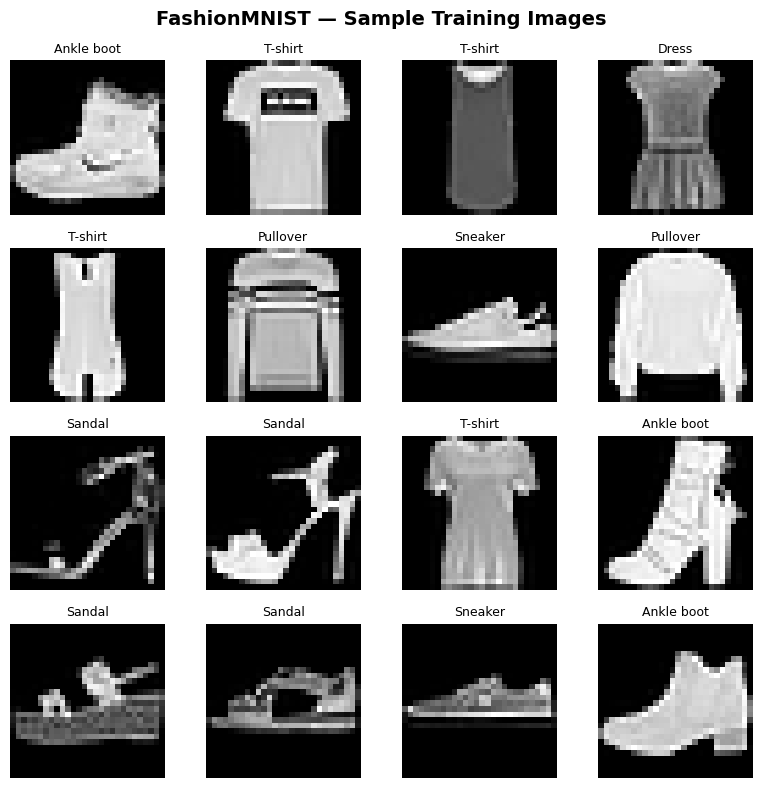

In [26]:
labels_map = {
    0: "T-shirt",  1: "Trouser",  2: "Pullover", 3: "Dress",  4: "Coat",
    5: "Sandal",   6: "Shirt",    7: "Sneaker",   8: "Bag",    9: "Ankle boot"
}

# Plot a 4×4 grid of training samples
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
fig.suptitle("FashionMNIST — Sample Training Images", fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    img, label = train_data[i]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(labels_map[label], fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

---
## Section 9: Custom Datasets

In real projects, you'll have your **own** images or CSV data. Here's how to build a custom `Dataset`.

### The 3-Method Contract

Every custom dataset inherits from `torch.utils.data.Dataset` and must implement:

| Method | Purpose |
|---|---|
| `__init__` | Load / store file paths and labels |
| `__len__` | Return total number of samples |
| `__getitem__(idx)` | Load and return sample at index `idx` |

In [27]:
import pandas as pd
import os
from PIL import Image
from torch.utils.data import Dataset

class CustomImageDataset(Dataset):
    """
    Template custom dataset for image classification.

    Expects:
        annotations_file : CSV with columns [filename, label]
        img_dir          : directory containing the image files
    """
    def __init__(self, annotations_file, img_dir, transform=None):
        self.labels     = pd.read_csv(annotations_file)  # load label CSV
        self.img_dir    = img_dir
        self.transform  = transform

    def __len__(self):
        # tell the DataLoader how many samples exist
        return len(self.labels)

    def __getitem__(self, idx):
        # Build the full path to image
        img_path = os.path.join(self.img_dir, self.labels.iloc[idx, 0])
        image    = Image.open(img_path).convert("RGB")
        label    = int(self.labels.iloc[idx, 1])

        if self.transform:
            image = self.transform(image)

        return image, label

print("✅ CustomImageDataset class defined.")
print("Usage example:")
print("  ds = CustomImageDataset('labels.csv', 'images/', transform=transforms.ToTensor())")
print("  dl = DataLoader(ds, batch_size=32, shuffle=True)")

✅ CustomImageDataset class defined.
Usage example:
  ds = CustomImageDataset('labels.csv', 'images/', transform=transforms.ToTensor())
  dl = DataLoader(ds, batch_size=32, shuffle=True)


In [28]:
# Demo: custom dataset from in-memory data
# (No files needed — great for testing the pattern)

class ToyDataset(Dataset):
    """Fake dataset: X = random vectors, y = random class labels"""
    def __init__(self, n_samples=100, n_features=10, n_classes=3):
        self.X = torch.randn(n_samples, n_features)
        self.y = torch.randint(0, n_classes, (n_samples,))

    def __len__(self):           return len(self.X)
    def __getitem__(self, idx):  return self.X[idx], self.y[idx]

toy = ToyDataset(n_samples=200)
toy_loader = DataLoader(toy, batch_size=16, shuffle=True)

print("ToyDataset length  :", len(toy))
print("Number of batches  :", len(toy_loader))

X_sample, y_sample = toy[0]
print("Single sample X shape:", X_sample.shape)
print("Single sample y      :", y_sample)

ToyDataset length  : 200
Number of batches  : 13
Single sample X shape: torch.Size([10])
Single sample y      : tensor(1)


---
## Section 10 — Building a Neural Network

### 📖 `nn.Module` — the Foundation of Every PyTorch Model

```
class YourModel(nn.Module):
    def __init__(self):        # define layers here
    def forward(self, x):      # define computation here (data flows through)
```

PyTorch calls `forward()` automatically when you do `model(input)`.

### Our Network Architecture

```
Input: 28×28 image  →  Flatten  →  784 nodes
                     →  Linear(784 → 512)  →  ReLU
                     →  Linear(512 → 256)  →  ReLU  
                     →  Linear(256 → 10)
Output: 10 logits (one per class)
```

In [29]:
import torch.nn as nn

class NeuralNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()          # [1, 28, 28] → [784]

        self.linear_stack = nn.Sequential(
            nn.Linear(28*28, 512),           # fully connected
            nn.ReLU(),                        # activation function
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 10)               # 10 output classes
        )

    def forward(self, x):
        x = self.flatten(x)                  # flatten image
        logits = self.linear_stack(x)        # pass through layers
        return logits                        # raw scores (not probabilities)

model = NeuralNet().to(device)
print(model)

NeuralNet(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [30]:
# Count parameters
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters    : 535,818
Trainable parameters: 535,818


In [31]:
# Test forward pass with dummy input
dummy_input = torch.rand(1, 1, 28, 28).to(device)  # 1 image, 1 channel, 28×28
output = model(dummy_input)

print("Input shape : ", dummy_input.shape)
print("Output shape:", output.shape)    # should be [1, 10] — 10 class scores
print("Output (raw logits):", output)

Input shape :  torch.Size([1, 1, 28, 28])
Output shape: torch.Size([1, 10])
Output (raw logits): tensor([[ 0.0536,  0.0556, -0.0373, -0.0444, -0.0595,  0.0638,  0.0469, -0.0868,
         -0.0902, -0.1052]], device='cuda:0', grad_fn=<AddmmBackward0>)


### 📖 What is ReLU?

**ReLU (Rectified Linear Unit)** is an activation function: `f(x) = max(0, x)`

- Negative values → 0
- Positive values → unchanged

**Why?** Without activation functions, stacking linear layers is still just a linear function — no learning power. ReLU adds non-linearity, letting the network learn complex patterns.

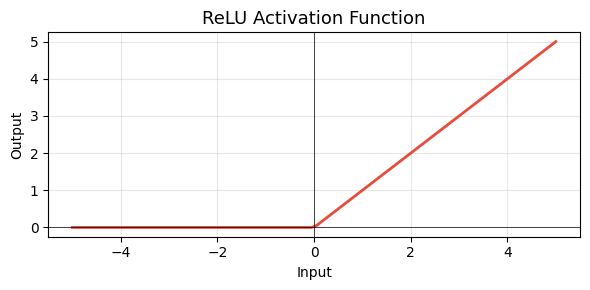

In [32]:
# Visualise ReLU
x = torch.linspace(-5, 5, 100)
relu = nn.ReLU()

plt.figure(figsize=(6, 3))
plt.plot(x.numpy(), relu(x).numpy(), color='#E74C3C', linewidth=2)
plt.title("ReLU Activation Function", fontsize=13)
plt.xlabel("Input")
plt.ylabel("Output")
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Section 11 — Loss Function & Optimizer

### 📖 Loss Function

Measures **how wrong** the model's predictions are. The goal of training is to minimise this number.

| Task | Loss Function |
|---|---|
| Multi-class classification | `CrossEntropyLoss` |
| Binary classification | `BCEWithLogitsLoss` |
| Regression | `MSELoss`, `L1Loss` |

### 📖 Optimizer

Uses the gradients computed by autograd to **update weights** and reduce the loss.

| Optimizer | Notes |
|---|---|
| `SGD` | Simple, classic, needs momentum tuning |
| `Adam` | Best default: adapts learning rate per weight |
| `AdamW` | Adam + weight decay (regularisation) |

In [33]:
# ─── Loss Function ────────────────────────────────────────────────
loss_fn = nn.CrossEntropyLoss()

# Optimizer
# lr (learning rate) = how big a step to take when updating weights
# Too high → unstable, oscillates  |  Too low → trains very slowly
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print("Loss function :", loss_fn)
print("Optimizer     :", optimizer)

Loss function : CrossEntropyLoss()
Optimizer     : Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [34]:
# Understand CrossEntropyLoss
# Fake batch: 4 samples, 3 classes
torch.manual_seed(0)
logits = torch.randn(4, 3)   # raw model output (not probabilities)
labels = torch.tensor([0, 2, 1, 0])  # true class indices

loss = nn.CrossEntropyLoss()(logits, labels)
print("Logits (raw output):\n", logits)
print("\nTrue labels:", labels)
print("\nLoss:", loss.item(), "  ← model should minimise this")

# Perfect predictions should give loss ~0
perfect_logits = torch.tensor([[10.0, -10, -10],  # class 0
                                 [-10, -10, 10.0],  # class 2
                                 [-10, 10.0, -10],  # class 1
                                 [10.0, -10, -10]]) # class 0
perfect_loss = nn.CrossEntropyLoss()(perfect_logits, labels)
print("\nPerfect predictions loss:", perfect_loss.item(), "  ← near zero ✅")

Logits (raw output):
 tensor([[ 1.5410, -0.2934, -2.1788],
        [ 0.5684, -1.0845, -1.3986],
        [ 0.4033,  0.8380, -0.7193],
        [-0.4033, -0.5966,  0.1820]])

True labels: tensor([0, 2, 1, 0])

Loss: 1.082031011581421   ← model should minimise this

Perfect predictions loss: 0.0   ← near zero ✅


---
## Section 12 — The Training Loop

### 📖 One Training Step (The Loop in Words)

```
for each batch:
   1. Forward pass  →  model(X) = predictions
   2. Compute loss  →  loss_fn(predictions, y)
   3. Zero old gradients  →  optimizer.zero_grad()
   4. Backward pass  →  loss.backward()   [autograd computes ∂loss/∂weight]
   5. Update weights →  optimizer.step()
```

> **Why zero_grad()?** By default, PyTorch *accumulates* gradients. If you forget this step, gradients from the previous batch are added, causing incorrect weight updates.

In [35]:
def train_one_epoch(dataloader, model, loss_fn, optimizer):
    model.train()          # set to training mode (enables dropout, batchnorm, etc.)
    total_loss = 0.0
    correct    = 0
    total      = 0

    for batch_idx, (X, y) in enumerate(dataloader):
        # Step 0: move data to the same device as the model
        X, y = X.to(device), y.to(device)

        # Step 1: Forward pass
        pred = model(X)

        # Step 2: Compute loss
        loss = loss_fn(pred, y)

        # Step 3: Zero previous gradients
        optimizer.zero_grad()

        # Step 4: Backward pass (compute gradients)
        loss.backward()

        # Step 5: Update weights
        optimizer.step()

        # Track metrics
        total_loss += loss.item()
        predicted   = pred.argmax(dim=1)
        correct    += (predicted == y).sum().item()
        total      += y.size(0)

        # Print progress every 200 batches
        if batch_idx % 200 == 0:
            print(f"  Batch {batch_idx:>4}/{len(dataloader)}  "
                  f"loss: {loss.item():.4f}")

    avg_loss = total_loss / len(dataloader)
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy

print("✅ train_one_epoch() defined")

✅ train_one_epoch() defined


---
## Section 13 — Evaluation Loop

In [36]:
def evaluate(dataloader, model, loss_fn):
    model.eval()          # set to evaluation mode (disables dropout, etc.)
    total_loss = 0.0
    correct    = 0
    total      = 0

    with torch.no_grad():  # no gradients needed during evaluation
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)

            total_loss += loss_fn(pred, y).item()
            predicted   = pred.argmax(dim=1)
            correct    += (predicted == y).sum().item()
            total      += y.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy

print("✅ evaluate() defined")

✅ evaluate() defined


---
## Section 12+13 — Train the Model (Full Run)

Now we bring everything together! We'll train for **10 epochs** and watch the model improve.

In [37]:
# Re-initialise fresh model & optimizer for the full run
model     = NeuralNet().to(device)
loss_fn   = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# History
history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

EPOCHS = 10

print("🚀 Starting training on:", device)
print("=" * 60)

for epoch in range(1, EPOCHS + 1):
    print(f"\n📌 Epoch {epoch}/{EPOCHS}")
    print("-" * 40)

    train_loss, train_acc = train_one_epoch(train_loader, model, loss_fn, optimizer)
    test_loss,  test_acc  = evaluate(test_loader,  model, loss_fn)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(f"  Train — loss: {train_loss:.4f}  acc: {train_acc:.1f}%")
    print(f"  Test  — loss: {test_loss:.4f}  acc: {test_acc:.1f}%")

print("\n" + "=" * 60)
print(f"✅ Training complete! Final test accuracy: {history['test_acc'][-1]:.1f}%")

🚀 Starting training on: cuda

📌 Epoch 1/10
----------------------------------------
  Batch    0/938  loss: 2.2945
  Batch  200/938  loss: 0.4415
  Batch  400/938  loss: 0.5943
  Batch  600/938  loss: 0.5570
  Batch  800/938  loss: 0.3449
  Train — loss: 0.4915  acc: 82.3%
  Test  — loss: 0.4133  acc: 84.7%

📌 Epoch 2/10
----------------------------------------
  Batch    0/938  loss: 0.2902
  Batch  200/938  loss: 0.3244
  Batch  400/938  loss: 0.3397
  Batch  600/938  loss: 0.4073
  Batch  800/938  loss: 0.3981
  Train — loss: 0.3578  acc: 86.8%
  Test  — loss: 0.3935  acc: 85.9%

📌 Epoch 3/10
----------------------------------------
  Batch    0/938  loss: 0.2098
  Batch  200/938  loss: 0.4302
  Batch  400/938  loss: 0.2350
  Batch  600/938  loss: 0.3255
  Batch  800/938  loss: 0.3751
  Train — loss: 0.3189  acc: 88.3%
  Test  — loss: 0.3777  acc: 86.6%

📌 Epoch 4/10
----------------------------------------
  Batch    0/938  loss: 0.2242
  Batch  200/938  loss: 0.1926
  Batch  400/9

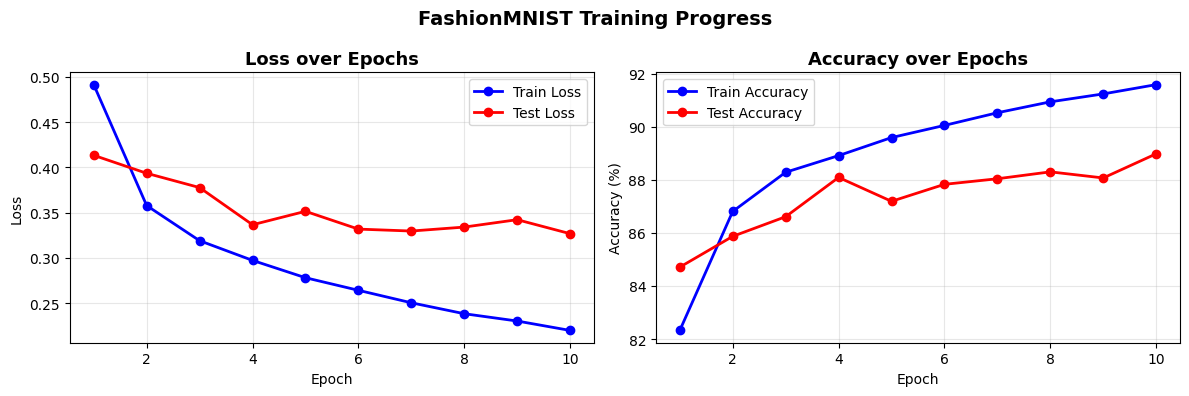

In [38]:
# Plot training curves
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(epochs_range, history["train_loss"], 'b-o', label="Train Loss", linewidth=2)
axes[0].plot(epochs_range, history["test_loss"],  'r-o', label="Test Loss",  linewidth=2)
axes[0].set_title("Loss over Epochs",     fontsize=13, fontweight='bold')
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, history["train_acc"], 'b-o', label="Train Accuracy", linewidth=2)
axes[1].plot(epochs_range, history["test_acc"],  'r-o', label="Test Accuracy",  linewidth=2)
axes[1].set_title("Accuracy over Epochs", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("FashionMNIST Training Progress", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 14 — Save & Load Models

### Two Approaches

| Method | Saves | Use when |
|---|---|---|
| `state_dict` (recommended) | Only the weights | You have the model class in your code |
| Entire model | Weights + architecture | Sharing with others who don't have your code |

In [39]:
# Method 1 (RECOMMENDED): save state_dict
torch.save(model.state_dict(), "fashion_mnist_model.pth")
print("✅ Model weights saved to fashion_mnist_model.pth")

# Load state_dict
loaded_model = NeuralNet().to(device)             # create empty model with same architecture
loaded_model.load_state_dict(torch.load("fashion_mnist_model.pth", map_location=device))
loaded_model.eval()                               # set to eval mode

print("✅ Model weights loaded successfully")

# Verify it matches the original
test_loss_new, test_acc_new = evaluate(test_loader, loaded_model, loss_fn)
print(f"✅ Loaded model test accuracy: {test_acc_new:.1f}%  (should match {history['test_acc'][-1]:.1f}%)")

✅ Model weights saved to fashion_mnist_model.pth
✅ Model weights loaded successfully
✅ Loaded model test accuracy: 89.0%  (should match 89.0%)


In [41]:
torch.save(model, "fashion_mnist_full.pth")
print("✅ Full model saved")

# Load the entire model (no need to re-define the class)
full_loaded = torch.load("fashion_mnist_full.pth", map_location=device, weights_only=False)
full_loaded.eval()
print("✅ Full model loaded")

✅ Full model saved
✅ Full model loaded


---
## Section 15 — Make Predictions

Let's see what the model actually predicts on some test images.

Predicted : Ankle boot (99.7% confidence)
Actual    : Ankle boot


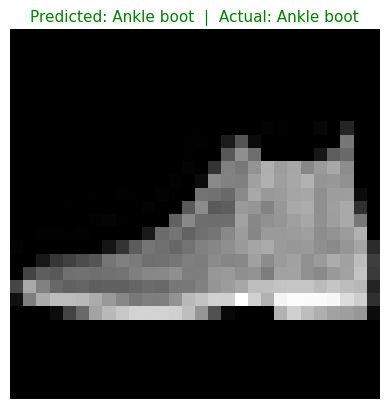

In [42]:
import torch.nn.functional as F

# Predict a single sample
sample_img, true_label = test_data[0]

model.eval()
with torch.no_grad():
    # Add batch dimension: [1, 28, 28] → [1, 1, 28, 28]
    logits      = model(sample_img.unsqueeze(0).to(device))
    probs       = F.softmax(logits, dim=1)        # convert to probabilities
    pred_class  = probs.argmax(dim=1).item()
    confidence  = probs.max().item() * 100

print(f"Predicted : {labels_map[pred_class]} ({confidence:.1f}% confidence)")
print(f"Actual    : {labels_map[true_label]}")

# Show the image
plt.imshow(sample_img.squeeze(), cmap="gray")
colour = "green" if pred_class == true_label else "red"
plt.title(f"Predicted: {labels_map[pred_class]}  |  Actual: {labels_map[true_label]}",
          color=colour, fontsize=11)
plt.axis("off")
plt.show()

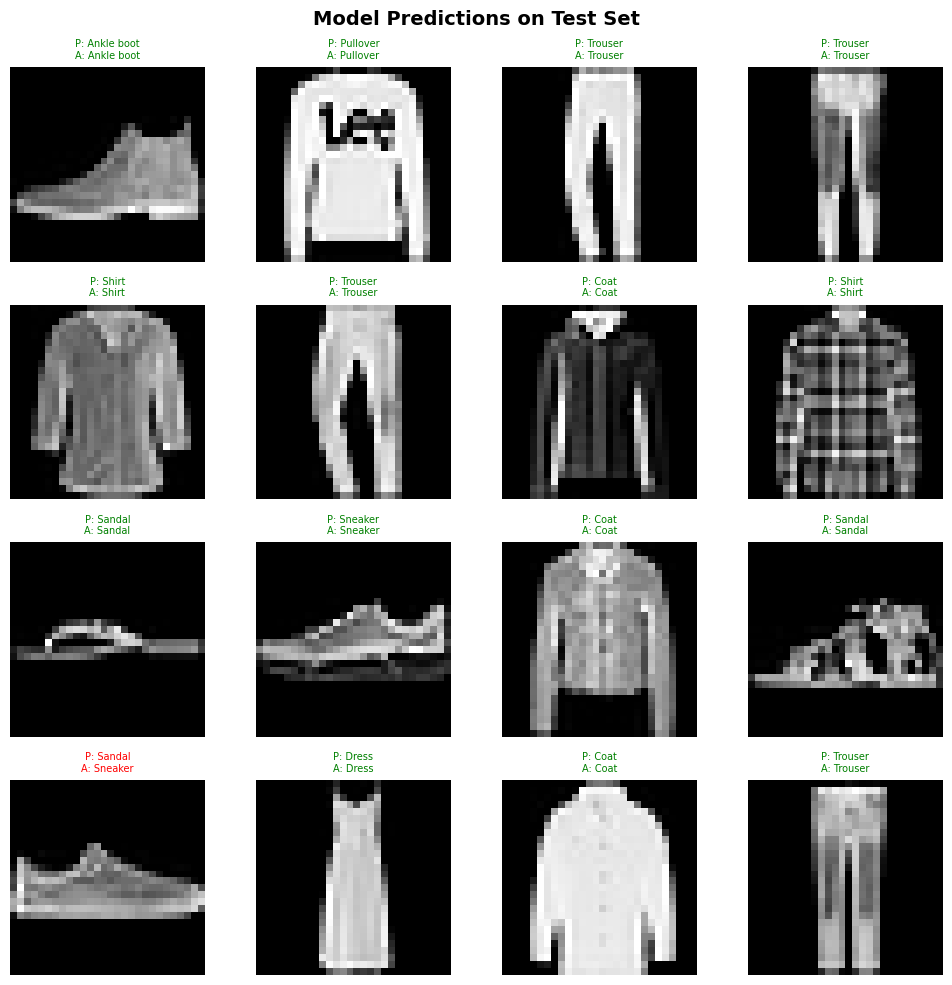

Green title = correct ✅ | Red title = wrong ❌


In [43]:
# Visualise predictions on a grid of 16 images
model.eval()
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("Model Predictions on Test Set", fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    img, true_label = test_data[i]

    with torch.no_grad():
        logits = model(img.unsqueeze(0).to(device))
        pred   = logits.argmax(1).item()

    ax.imshow(img.squeeze(), cmap="gray")
    colour = "green" if pred == true_label else "red"
    ax.set_title(f"P: {labels_map[pred]}\nA: {labels_map[true_label]}",
                 color=colour, fontsize=7)
    ax.axis("off")

plt.tight_layout()
plt.show()
print("Green title = correct ✅ | Red title = wrong ❌")

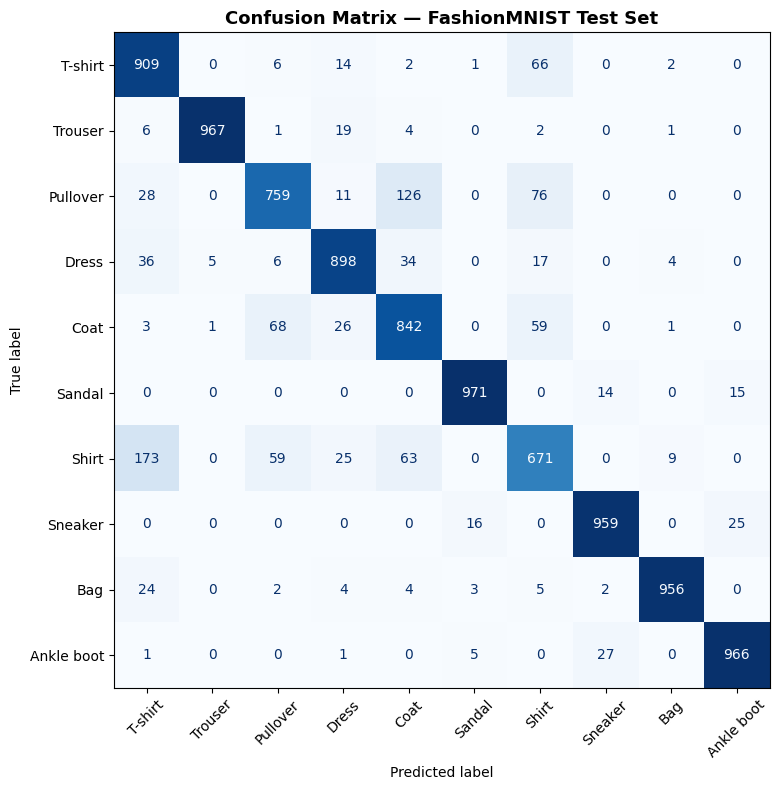

In [44]:
# Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_preds  = []
all_labels = []

model.eval()
with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        pred = model(X).argmax(1).cpu()
        all_preds.extend(pred.numpy())
        all_labels.extend(y.numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(labels_map.values())
)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, colorbar=False, cmap="Blues", xticks_rotation=45)
ax.set_title("Confusion Matrix — FashionMNIST Test Set", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Summary - What You've Built

```
Raw grayscale images (28×28 px)
        ↓
   FashionMNIST Dataset + DataLoader
        ↓
   NeuralNet (3 Linear layers + ReLU)
        ↓
   CrossEntropyLoss + Adam optimiser
        ↓
   Training Loop (10 epochs)
        ↓
   ~88% test accuracy 🎉
```

### Concepts Mastered

| Concept | What you did |
|---|---|
| **Tensors** | Created, reshaped, indexed, operated on |
| **Data Types** | float32, int64, dtype casting |
| **GPU** | Moved tensors and model to `device`, saw speedup |
| **Autograd** | Computed gradients with `.backward()` |
| **Dataset/DataLoader** | Built FashionMNIST pipeline + custom dataset |
| **nn.Module** | Defined multi-layer network with `forward()` |
| **Training loop** | Forward → Loss → Zero grad → Backward → Step |
| **Evaluation** | `model.eval()` + `torch.no_grad()` |
| **Save/Load** | `state_dict` (recommended) + full model |
| **Inference** | Softmax probabilities, visualisation, confusion matrix |

---

## Next Steps

| Path | What to learn |
|---|---|
| **CNNs** | `nn.Conv2d` — far better accuracy on images |
| **Transfer Learning** | Fine-tune ResNet50 on your own data |
| **Custom Data** | Load your own image folder with `ImageFolder` |
| **Regularisation** | Dropout, BatchNorm to fight overfitting |
| **Deployment** | TorchScript, ONNX, HuggingFace Spaces |

---

**📚 Reference:** [PyTorch Official Tutorial](https://pytorch.org/tutorials/beginner/basics/intro.html)

**👨‍🏫 Project Engineer:** Lovnish Verma — NIELIT Ropar | [@lovnishverma](https://github.com/lovnishverma)